In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from diffuser.diffuser_ddpm_linear_schedule import Diffuser_DDPM_linear_schedule 
from diffuser.unet import DiffusionUNet

# Set import root to project root, to find dataset_loader and vae 
sys.path.insert(0, os.path.abspath(os.path.join("..")))
from dataset_loader import load_dataset
from vae.vae import VAE

from repa.config import ExperimentConfig
from repa.models.wrapper import REPAWrapper
from repa.train import DiffusionTrainer
from repa.models.factory import build_student_model

# Config:
from diffuser.unet_config import DiffuserConfig

c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project\DSAIT4030-group12\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [2]:
#Init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_string = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

torch.manual_seed(0)
np.random.seed(0)

cpu


In [3]:
# Create scheduler model
ddpm_model = Diffuser_DDPM_linear_schedule(total_timesteps=1000, beta_start=0.0001, beta_end=0.02)

ddpm_model.betas = ddpm_model.betas.to(device)
ddpm_model.alphas = ddpm_model.alphas.to(device)
ddpm_model.alpha_bars = ddpm_model.alpha_bars.to(device)

In [4]:
# Create model
config = DiffuserConfig()
unet = DiffusionUNet(
    config=config,
    model_in_channels=4,
    model_out_channels=4
).to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-6)


In [5]:
# Checkpointing: load existing checkpoint if available and helper to save checkpoints
checkpoint_dir = os.path.abspath(os.path.join('..', 'checkpoints'))
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_last = os.path.join(checkpoint_dir, 'checkpoint_last.pt')

start_step = 0

def save_checkpoint(step):
    ck = {
        'step': int(step),
        'unet_state': unet.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }
    if hasattr(ddpm_model, 'state_dict'):
        try:
            ck['ddpm_state'] = ddpm_model.state_dict()
        except Exception:
            pass
    torch.save(ck, os.path.join(checkpoint_dir, f'ckpt_step_{step}.pt'))
    torch.save(ck, checkpoint_last)
    print(f'Saved checkpoint for step {step} ->', os.path.join(checkpoint_dir, f'ckpt_step_{step}.pt'))

In [6]:
# Loads data and uses VAE to generate latents
def load_data(NUM_WORKERS, BATCH_SIZE, DATASET):
    train_set = load_dataset(DATASET, split="train")

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
        persistent_workers=True if NUM_WORKERS > 0 else False,
    )

    return train_loader

# Sampling

In [7]:
@torch.no_grad()
def sample(model, ddpm, shape, fixed_noise=None):
    model.eval()

    x = torch.randn(shape, device=device)

    if fixed_noise != None:
        x = fixed_noise

    for t in range(ddpm.total_timesteps - 1, 0, -1):
        ts = torch.full((shape[0],), t, device=device, dtype=torch.long).view(-1)
        pred_noise = model(x, ts)
        x = ddpm.reverse_diffusion(x, ts, pred_noise)

    return x

In [8]:
def show_images(img_batch, title=None):

    while hasattr(img_batch, "sample"):
        img_batch = img_batch.sample

    img_batch = img_batch.detach().cpu()
    fig, axes = plt.subplots(1, img_batch.shape[0], figsize=(4 * img_batch.shape[0], 4))
    if img_batch.shape[0] == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = img_batch[i]
        img = (img + 1.0) / 2.0
        img = (img * 255.0).clamp(0, 255).byte()
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

# Run and Show

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8901.97it/s]
c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project\DSAIT4030-group12\venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project


c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project\DSAIT4030-group12\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project\DSAIT4030-group12\repa\train.py:66: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=self.device_type, dtype=self.dtype):
c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project\DSAIT4030-group12\repa\train.py:40: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=self.device_type, dtype=self.dtype):


step     0 | loss 1.1130 | diff 1.1120 | repa 0.0024


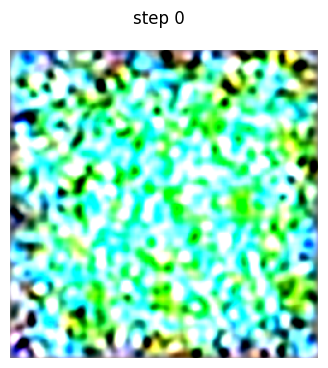

c:\Users\jaspe\Documents\Github_projects\Generative_Modelling_Project


In [ ]:
# training loop:
num_steps = 10000
batch_size = 256
minibatch_size = 16
num_workers = 0

print_loss_every = 25
preview_every = 100

save_every = 400  # steps - set to 0 to disable periodic saving

# Config for REPA-DoG
config = ExperimentConfig(
    data_dir="../data",
    dataset_name="celeba",
    output_dir="../results/unet_dog",
    max_steps=30000,
    batch_size=16,
    lr=1e-4,
    model_type="unet",
    mode="dog",  # or "repa", "irepa", "vanilla"
    lambda_repa=1.0,  # 0.4 for REPA, 1.0 for DoG/iREPA
    num_evals=40,
    num_eval_images=2000
)

student_model, meta = build_student_model(config.model_type)
wrapper = REPAWrapper(unet, meta, config)
wrapper.student.train()
trainer = DiffusionTrainer(wrapper, learning_rate=1e-4, lambda_repa=1.0)

# Use start_step from checkpoint (if resumed) otherwise 0
for i in range(start_step, num_steps):
    print("step ", i)
    train_loader = load_data(num_workers, minibatch_size, "celeba")
    data_i = iter(train_loader)
    
    batch = next(data_i)
    images = batch["images"].to(trainer.device)

    with torch.amp.autocast(device_type=device_string, dtype=torch.bfloat16):
        losses = trainer.train_step(images)

    loss = losses["loss_total"]

    if i % print_loss_every == 0:
        print(f"step {i:5d} | loss {loss:.4f} | diff {losses['loss_diff']:.4f} | repa {losses['loss_repa']:.4f}")

    if i % preview_every == 0:
        wrapper.student.eval()
        with torch.no_grad():
            latent_samples = sample(wrapper.student, ddpm_model, (1, 4, 32, 32))
            samples = wrapper.vae.decode(latent_samples)
        show_images(samples, title=f"step {i}")
        wrapper.student.train()

    # periodic checkpoint save
    if save_every and save_every > 0 and (i % save_every == 0) and i != start_step:
        save_checkpoint(i)


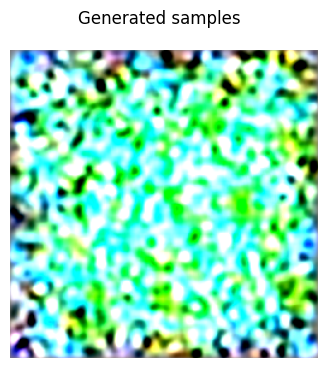

In [10]:
show_images(samples, title="Generated samples")

In [11]:
with torch.no_grad():
    samples = wrapper.vae.decode(sample(wrapper.student, ddpm_model, (1, 4, 32, 32)))
